# Exploratory Data Analysis

Three datasets:
1. **News Category Dataset** (HuffPost, ~210k articles) — Kaggle: `rmisra/news-category-dataset`
2. **Million Headlines** (ABC Australia, ~1M headlines) — Kaggle: `therohk/million-headlines`
3. **EMDAT** — Global disaster events database (local CSV)

## Setup

Run this cell first. It installs `kagglehub` if needed and imports all libraries.

In [12]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

for pkg in ["kagglehub", "pandas", "matplotlib", "seaborn", "openpyxl"]:
    install(pkg)

import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
print("All libraries loaded.")

All libraries loaded.


---
## Dataset 1: News Category Dataset (HuffPost)

~210,000 news articles with categories, headlines, short descriptions, and dates (2012–2022).  
Kaggle: `rmisra/news-category-dataset`

In [13]:
# Download dataset — first run may take a minute
path1 = kagglehub.dataset_download("rmisra/news-category-dataset")
print("Downloaded to:", path1)

# The file is a JSONL (one JSON object per line)
jsonl_file = [f for f in os.listdir(path1) if f.endswith(".json")][0]
with open(os.path.join(path1, jsonl_file), "r", encoding="utf-8") as f:
    news = pd.DataFrame([json.loads(line) for line in f])

print(f"Shape: {news.shape}")
news.head(3)

Downloaded to: C:\Users\nicot\.cache\kagglehub\datasets\rmisra\news-category-dataset\versions\3
Shape: (209527, 6)


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23


In [14]:
# Basic info
print("=== Data Types & Non-Null Counts ===")
news.info()

print("\n=== Missing Values ===")
print(news.isnull().sum())

print("\n=== Duplicate Rows ===")
print(news.duplicated().sum())

=== Data Types & Non-Null Counts ===
<class 'pandas.DataFrame'>
RangeIndex: 209527 entries, 0 to 209526
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   link               209527 non-null  str  
 1   headline           209527 non-null  str  
 2   category           209527 non-null  str  
 3   short_description  209527 non-null  str  
 4   authors            209527 non-null  str  
 5   date               209527 non-null  str  
dtypes: str(6)
memory usage: 9.6 MB

=== Missing Values ===
link                 0
headline             0
category             0
short_description    0
authors              0
date                 0
dtype: int64

=== Duplicate Rows ===
13


Date range: 2012-01-28 00:00:00 → 2022-09-23 00:00:00


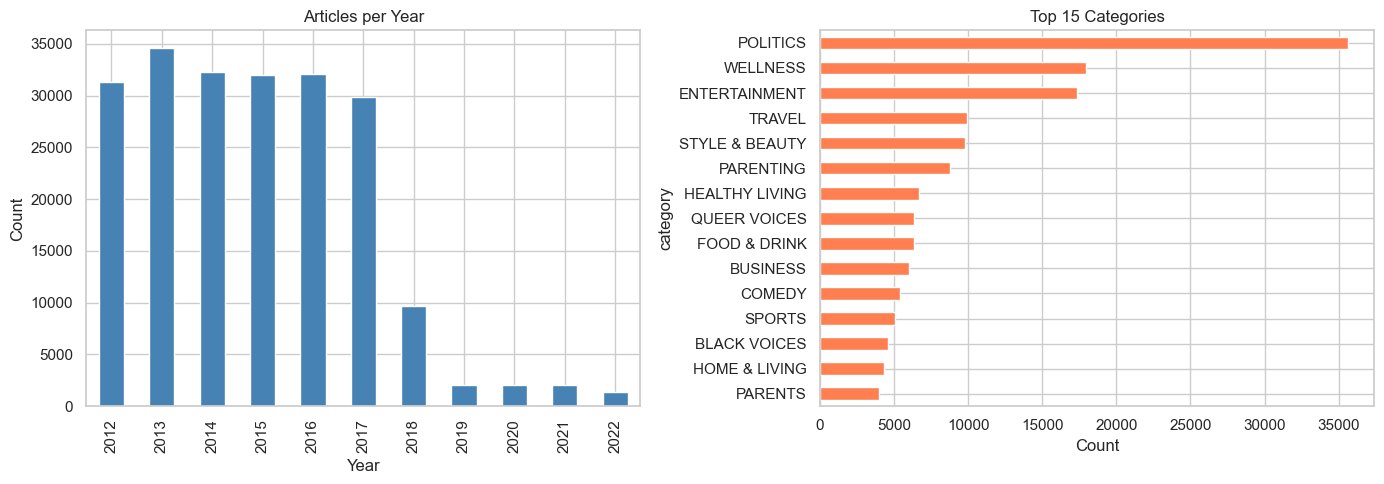

In [15]:
# Parse date and look at time coverage
news["date"] = pd.to_datetime(news["date"], errors="coerce")
print("Date range:", news["date"].min(), "→", news["date"].max())

# Articles per year
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

news["date"].dt.year.value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Articles per Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")

# Top 15 categories
news["category"].value_counts().head(15).plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Top 15 Categories")
axes[1].set_xlabel("Count")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

count    209527.000000
mean          9.600744
std           3.068507
min           0.000000
25%           8.000000
50%          10.000000
75%          12.000000
max          44.000000
Name: headline_len, dtype: float64


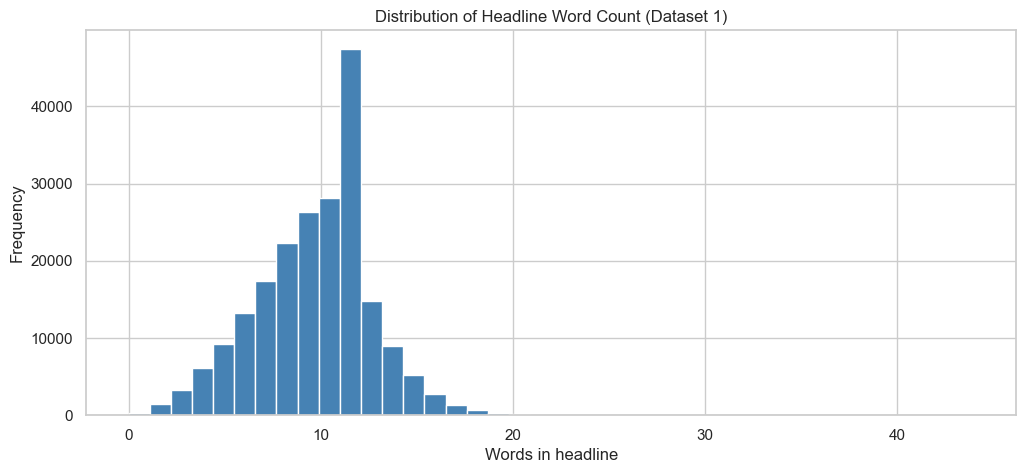

In [16]:
# Headline length distribution
news["headline_len"] = news["headline"].str.split().str.len()
print(news["headline_len"].describe())

news["headline_len"].plot(kind="hist", bins=40, color="steelblue", edgecolor="white")
plt.title("Distribution of Headline Word Count (Dataset 1)")
plt.xlabel("Words in headline")
plt.ylabel("Frequency")
plt.show()

---
## Dataset 2: Million Headlines (ABC Australia)

~1 million news headlines published by the Australian Broadcasting Corporation (2003–2021).  
Kaggle: `therohk/million-headlines`  
Columns: `publish_date`, `headline_text`

In [17]:
# Download dataset
path2 = kagglehub.dataset_download("therohk/million-headlines")
print("Downloaded to:", path2)

csv_file = [f for f in os.listdir(path2) if f.endswith(".csv")][0]
headlines = pd.read_csv(os.path.join(path2, csv_file))

print(f"Shape: {headlines.shape}")
headlines.head(3)

Downloaded to: C:\Users\nicot\.cache\kagglehub\datasets\therohk\million-headlines\versions\5
Shape: (1244184, 2)


,publish_date,headline_text
0,20030219,aba decides against community broadcasting lic...
1,20030219,act fire witnesses must be aware of defamation
2,20030219,a g calls for infrastructure protection summit


In [18]:
print("=== Missing Values ===")
print(headlines.isnull().sum())

print("\n=== Duplicates ===")
print(headlines.duplicated().sum())

# Parse date (format: YYYYMMDD integer)
headlines["publish_date"] = pd.to_datetime(headlines["publish_date"].astype(str), format="%Y%m%d", errors="coerce")
print(f"\nDate range: {headlines['publish_date'].min()} → {headlines['publish_date'].max()}")

=== Missing Values ===
publish_date     0
headline_text    0
dtype: int64

=== Duplicates ===
2

Date range: 2003-02-19 00:00:00 → 2021-12-31 00:00:00


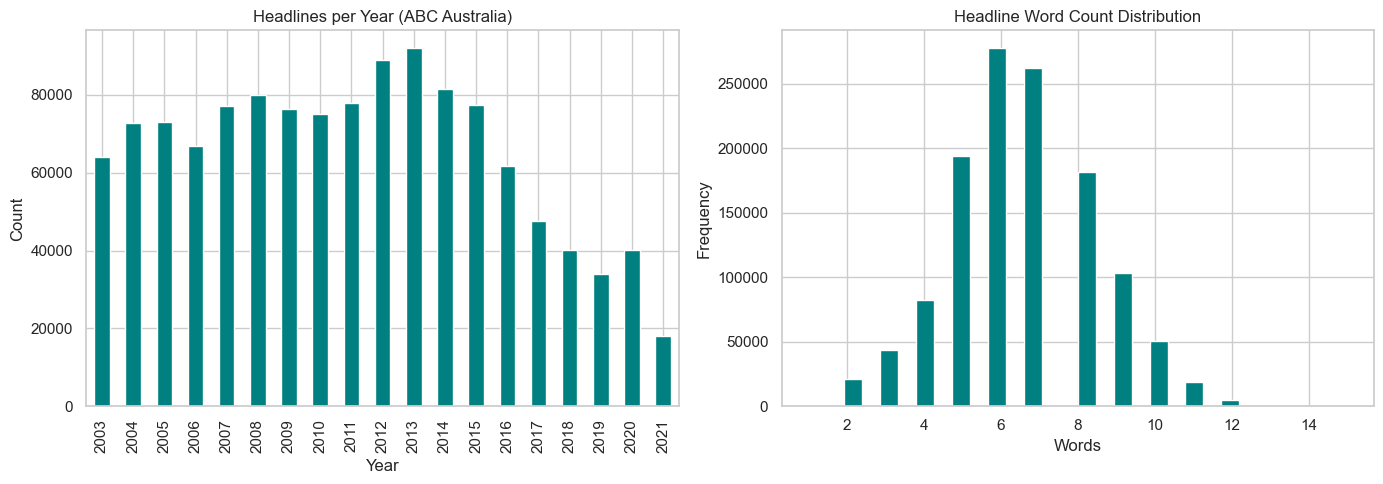

count    1.244184e+06
mean     6.557523e+00
std      1.868473e+00
min      1.000000e+00
25%      5.000000e+00
50%      7.000000e+00
75%      8.000000e+00
max      1.500000e+01
Name: word_count, dtype: float64


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Articles per year
headlines["publish_date"].dt.year.value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="teal"
)
axes[0].set_title("Headlines per Year (ABC Australia)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")

# Headline word count distribution
headlines["word_count"] = headlines["headline_text"].str.split().str.len()
headlines["word_count"].plot(kind="hist", bins=30, ax=axes[1], color="teal", edgecolor="white")
axes[1].set_title("Headline Word Count Distribution")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(headlines["word_count"].describe())

---
## Dataset 3: EMDAT — Global Disaster Events

The Emergency Events Database tracks natural and technological disasters worldwide.  
Local file: `data/EMDAT.csv` (semicolon-delimited)  
Key columns: Disaster Type, Country, Region, Start Year, Total Deaths, Total Affected, Total Damage

In [20]:
import os

# Set working directory to the project root
notebook_dir = os.path.dirname(os.path.abspath("eda.ipynb"))
os.chdir(notebook_dir)

emdat_path = os.path.join(notebook_dir, "data", "EMDAT.csv")

emdat = pd.read_csv(emdat_path, sep=";", encoding="latin-1", low_memory=False)

print(f"Shape: {emdat.shape}")
emdat.head(3)

Shape: (331, 47)


,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
0,2018-0111-USA,No,nat-met-sto-bli,Natural,Meteorological,Storm,Blizzard/Winter storm,NaN,NaN,USA,...,NaN,1400000.0,1748916.0,2300000.0,2873219.0,"80,04959626","[{""adm1_code"":3220,""adm1_name"":""Connecticut""},...","[{""gid_1"":""USA.21_1"",""migration_date"":""2025-12...",2018-04-13,2025-12-20
1,2016-0493-USA,No,nat-geo-ear-gro,Natural,Geophysical,Earthquake,Ground movement,USGS:us100075y8,NaN,USA,...,NaN,NaN,NaN,20000.0,26140.0,"76,5112162","[{""adm1_code"":3250,""adm1_name"":""Oklahoma""}]","[{""gid_1"":""USA.37_1"",""migration_date"":""2025-12...",2016-12-15,2026-01-25
2,2019-0306-USA,No,nat-geo-ear-gro,Natural,Geophysical,Earthquake,Ground movement,GLIDE:EQ-2019-000077|USGS:ci38457511,NaN,USA,...,NaN,50000.0,61349.0,200000.0,245398.0,"81,50030941","[{""adm2_code"":28879,""adm2_name"":""Kern""}]","[{""gid_2"":""USA.5.15_1"",""migration_date"":""2025-...",2019-07-09,2026-01-25


In [21]:
print("=== Columns ===")
print(list(emdat.columns))

print("\n=== Data Types ===")
emdat.info()

print("\n=== Missing Values (%) ===")
missing = (emdat.isnull().sum() / len(emdat) * 100).sort_values(ascending=False)
print(missing[missing > 0].round(1))

=== Columns ===
['DisNo.', 'Historic', 'Classification Key', 'Disaster Group', 'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype', 'External IDs', 'Event Name', 'ISO', 'Country', 'Subregion', 'Region', 'Location', 'Origin', 'Associated Types', 'OFDA/BHA Response', 'Appeal', 'Declaration', "AID Contribution ('000 US$)", 'Magnitude', 'Magnitude Scale', 'Latitude', 'Longitude', 'River Basin', 'Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day', 'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless', 'Total Affected', "Reconstruction Costs ('000 US$)", "Reconstruction Costs, Adjusted ('000 US$)", "Insured Damage ('000 US$)", "Insured Damage, Adjusted ('000 US$)", "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)", 'CPI', 'Admin Units', 'GADM Admin Units', 'Entry Date', 'Last Update']

=== Data Types ===
<class 'pandas.DataFrame'>
RangeIndex: 331 entries, 0 to 330
Data columns (total 47 columns):
 #   Column                                  

In [22]:
# Fix numeric columns that may have commas as decimal separators
for col in ["Total Deaths", "No. Affected", "Total Affected",
            "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)"]:
    if col in emdat.columns:
        emdat[col] = (
            emdat[col].astype(str)
            .str.replace(",", ".", regex=False)
            .str.replace(" ", "", regex=False)
            .pipe(pd.to_numeric, errors="coerce")
        )

print(emdat[["Start Year", "Total Deaths", "Total Affected",
             "Total Damage ('000 US$)"]].describe())

        Start Year  Total Deaths  Total Affected  Total Damage ('000 US$)
count   331.000000    254.000000    1.920000e+02             2.730000e+02
mean   2016.700906     15.350394    4.612040e+05             2.664681e+06
std       2.967189     28.228305    6.134154e+06             8.711129e+06
min    2012.000000      1.000000    1.000000e+00             2.000000e+03
25%    2014.000000      2.000000    1.090000e+02             1.750000e+05
50%    2016.000000      6.000000    4.440000e+02             9.500000e+05
75%    2019.000000     15.000000    3.262500e+03             2.000000e+06
max    2021.000000    235.000000    8.500001e+07             9.500000e+07


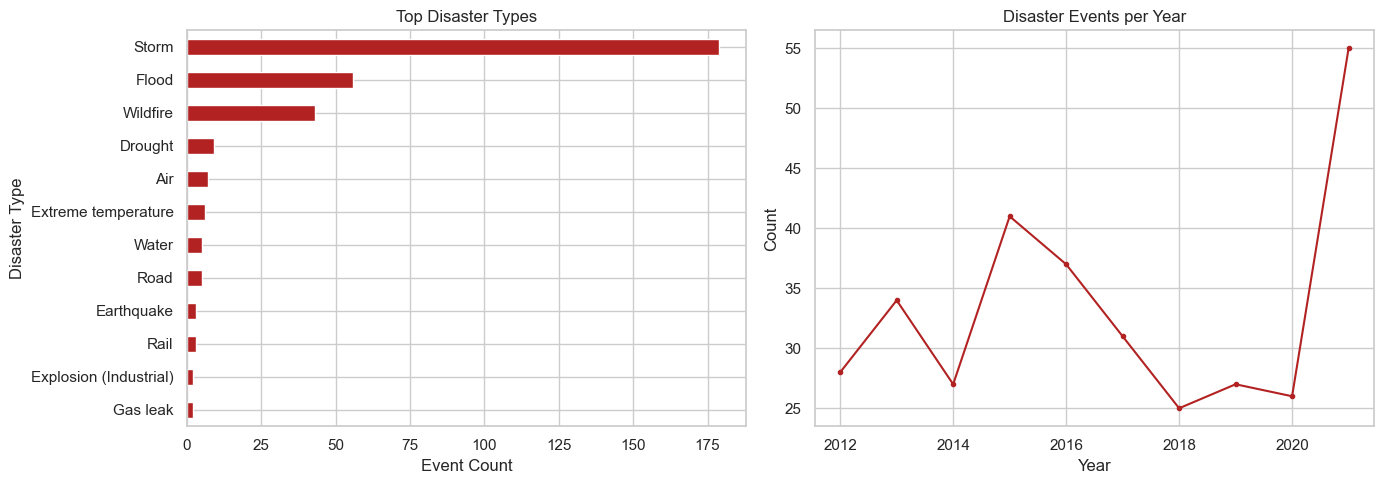

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Disaster type counts
emdat["Disaster Type"].value_counts().head(12).plot(
    kind="barh", ax=axes[0], color="firebrick"
)
axes[0].set_title("Top Disaster Types")
axes[0].set_xlabel("Event Count")
axes[0].invert_yaxis()

# Events per year
emdat["Start Year"].value_counts().sort_index().plot(
    kind="line", ax=axes[1], color="firebrick", marker="o", markersize=3
)
axes[1].set_title("Disaster Events per Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

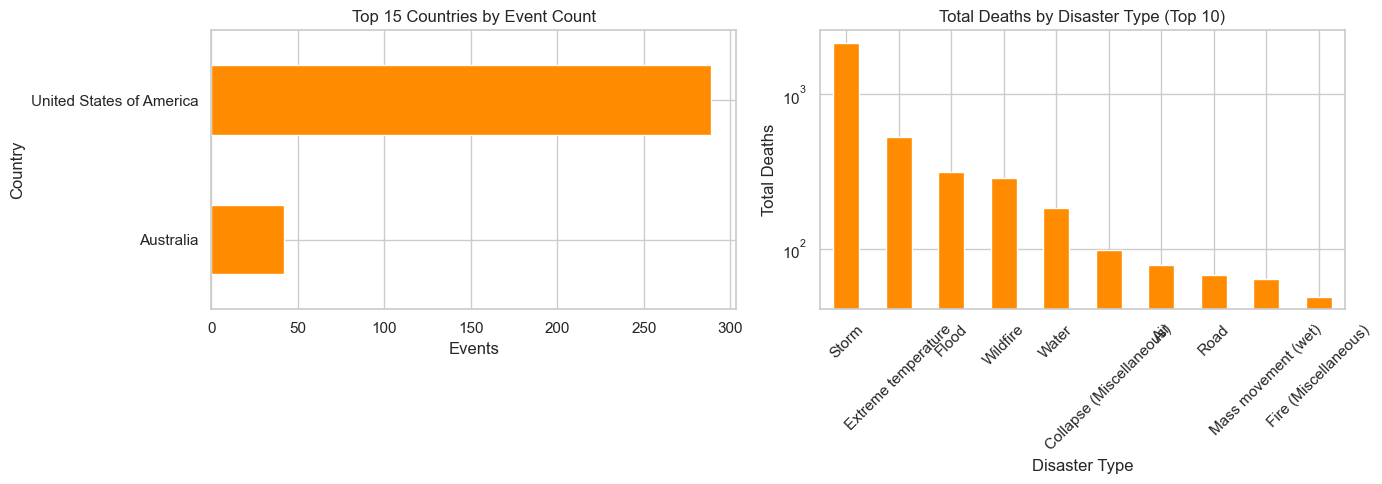

In [24]:
# Top 15 countries by event count
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

emdat["Country"].value_counts().head(15).plot(
    kind="barh", ax=axes[0], color="darkorange"
)
axes[0].set_title("Top 15 Countries by Event Count")
axes[0].set_xlabel("Events")
axes[0].invert_yaxis()

# Deaths by disaster type (sum, log scale)
deaths_by_type = (
    emdat.groupby("Disaster Type")["Total Deaths"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
deaths_by_type.plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Total Deaths by Disaster Type (Top 10)")
axes[1].set_ylabel("Total Deaths")
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()